<a href="https://colab.research.google.com/github/jaxa4ever-code/Support-Vector-Machine/blob/main/Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Evaluation Metrics ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



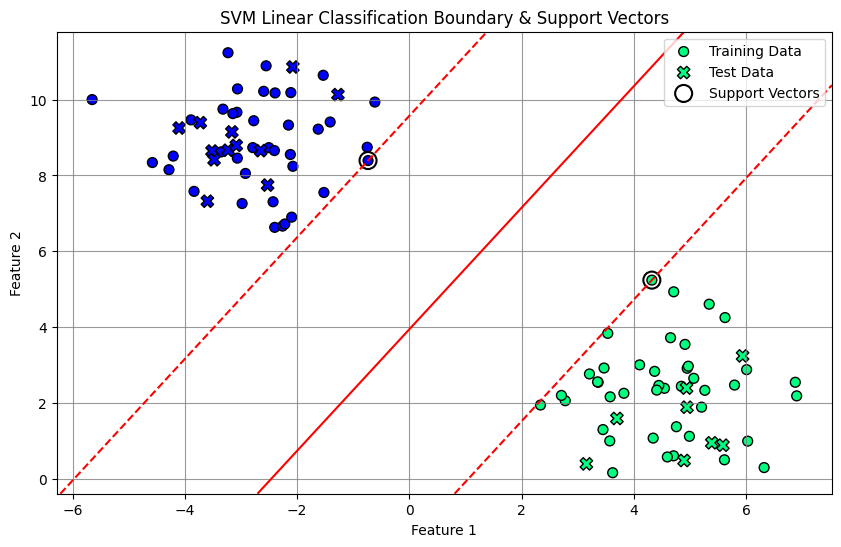

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

X, y = make_blobs(n_samples=100, centers=2, random_state=42, cluster_std=1.2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

print("--- Evaluation Metrics ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(10, 6))

plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='winter', s=50, edgecolors='black', label='Training Data')
# Plot the testing data points (with a different marker)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='winter', s=80, marker='X', edgecolors='black', label='Test Data')

# Get current axis limits to plot the decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create grid to evaluate model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Get the separating hyperplane
Z = svm_model.decision_function(xy).reshape(XX.shape)

# Plot decision boundary (Z=0) and margins (Z = -1 and Z = 1)
ax.contour(XX, YY, Z, colors='r', levels=[-1, 0, 1], alpha=1, linestyles=['--', '-', '--'])

# Highlight the Support Vectors
ax.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1], s=150,
           linewidth=1.5, facecolors='none', edgecolors='black', label='Support Vectors')

plt.title('SVM Linear Classification Boundary & Support Vectors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(alpha=0.8, color ='grey')
plt.legend()
plt.show()